In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
plt.style.use('./deeplearning.mplstyle')
import tensorflow as tf
from keras.models import Sequential
from keras.layers import Dense, LeakyReLU
from keras.activations import linear, relu, sigmoid
from keras import backend, layers 
%matplotlib widget
from matplotlib.widgets import Slider
from lab_utils_common import dlc
from autils import plt_act_trio
from lab_utils_relu import *
import warnings
warnings.simplefilter(action='ignore', category=UserWarning)


<a name="2"></a>
## 2 - ReLU激活函数
本周，引入了一种新的激活函数，即修正线性单元（ReLU Rectified Linear Unit）。
$$ a = max(0,z)$$

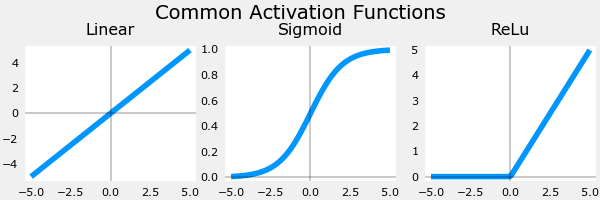

In [2]:
plt_act_trio()

<img align="right" src="../work/images/C2_W2_ReLu.png"     style=" width:380px; padding: 10px 20px; " >
右边讲座中的示例展示了ReLU的一种应用.   
   
在这个示例中，派生的 “awareness品牌认知度” 特征不是二进制的，而是具有连续的值范围。   

Sigmoid函数最适合开/关或二进制情况。      

ReLU提供了一种连续的线性关系。此外，它有一个 “关闭” 范围，在这个范围内输出为零。    

   

“关闭” 特征使ReLU成为一种非线性激活函数。为什么需要这样呢？下面我们来探讨一下。

### 为什么使用非线性激活函数？
<img align="left" src="../work/images/C2_W2_ReLU_Graph.png"     style=" width:250px; padding: 10px 20px; " > 
所示函数由线性片段组成（分段线性）。在线性部分，斜率保持一致，然后在过渡点突然变化。在过渡点，会添加一个新的线性函数，将其与现有函数相加，就会产生新的斜率。新函数在过渡点添加，但在该点之前对输出没有贡献。非线性激活函数负责在过渡点之前，有时甚至在过渡点之后，禁用输入。 

以下练习将给出一个更具体的例子。

本练习将在一个回归问题中使用以下网络，在该问题中，你必须对一个分段线性目标进行建模：
<img align="center" src="../work/images/C2_W2_ReLU_Network.png"     style=" width:650px; padding: 10px 20px; ">  
该网络的第一层有3个单元。每个单元将负责目标的一部分。单元0已预先编程并固定用于映射第一段。你将修改单元1和单元2中的权重和偏差，以对第二段和第三段进行建模。输出单元也已固定，仅对第一层的输出进行求和。 

使用下方的滑块，调整权重和偏差以匹配目标。提示：先从`w1`和`b1`开始，在匹配第二段之前，将`w2`和`b2`设为零。点击比滑动更快。如果你遇到困难，别担心，下方的文本将更详细地描述这一点。

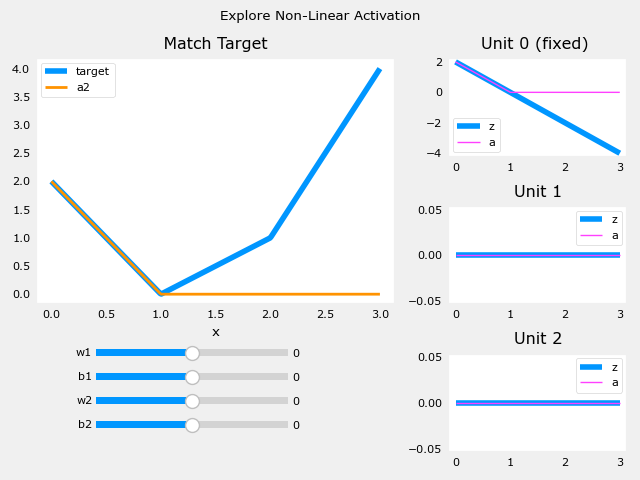

In [3]:
_ = plt_relu_ex()

本练习的目标是理解ReLU的非线性特性如何提供在需要时才启用函数的能力。让我们看看在这个例子中这是如何实现的。

<img align="top" src="../work/images/C2_W2_ReLU_Plot.png"     style=" width:600px; padding: 10px 20px; "> 

图包含了第一层单元的输出。从顶部开始，单元0负责标记为1的第一段。图中同时展示了线性函数$z$和经过ReLU激活后的函数$a$。可以看到，ReLU函数在区间[0,1]之后截断了函数。这一点很关键，因为它避免了对后续段的干扰。    

单元1负责第二段。在这里，ReLU函数使该单元在x达到1之前一直不产生输出。由于第一个单元没有贡献，单元1的斜率$w^{[1]}_1$，就只是目标直线的斜率。必须调整偏差，以确保在x达到1之前输出为负。   

单元2负责第三段。在x达到合适的值之前，ReLU函数再次将输出置零。必须设置该单元的斜率$w^{[1]}_2$，以便单元1和单元2的总和具有所需的斜率。同样要调整偏差，以确保在x达到2之前输出为负。   

ReLU激活函数的“关闭”或禁用特性使模型能够将线性段拼接在一起，以模拟复杂的非线性函数。

In [4]:
# =======新版课程到此为止=======

## 新激活函数
本周引入了一种新的激活函数，即修正线性单元（ReLU）。

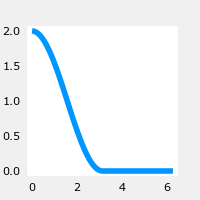

In [7]:
# 在0~2π之间，创建100个等距的数值
X = np.linspace(0,2*np.pi, 100)

#创建函数y，最小0，最大2
y = np.cos(X)+1
y[50:100]=0

fig,ax = plt.subplots(1,1, figsize=(2,2))

widgvis(fig) # 关闭页眉、页脚、工具栏的可见性
ax.plot(X,y)
plt.show()

In [8]:
w10 = np.array([[-1]])
b10 = np.array([2.6])

# 创建Dense层
d10 = Dense(1, activation = "linear")

# 构建模型（需要先构建才能设置权重）
input_tensor = tf.keras.Input(shape=(1,))
output_tensor = d10(input_tensor)

# 设置权重和偏置
d10.set_weights([w10, b10])

z10 = d10(X.reshape(-1,1))
a10 = relu(z10)

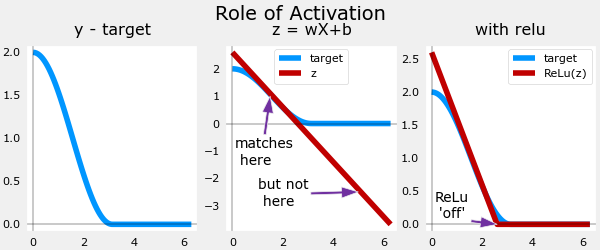

In [9]:
def plt_act1(y,z,a):
    fig,ax = plt.subplots(1,3, figsize=(6,2.5))
    widgvis(fig)
    ax[0].plot(X,y,label="target")
    ax[0].axvline(0, lw=0.3, c="black")
    ax[0].axhline(0, lw=0.3, c="black")
    ax[0].set_title("y - target")
    
    ax[1].plot(X,y, label="target")
    ax[1].plot(X,z, c=dlc["dldarkred"],label="z")
    ax[1].axvline(0, lw=0.3, c="black")
    ax[1].axhline(0, lw=0.3, c="black")
    ax[1].set_title("z = wX+b")
    ax[1].legend(loc="upper center")
    
    ax[2].plot(X,y, label="target")
    ax[2].plot(X,a, c=dlc["dldarkred"],label="ReLu(z)")
    ax[2].axhline(0, lw=0.3, c="black")
    ax[2].axvline(0, lw=0.3, c="black")
    ax[2].set_title("with relu")
    ax[2].legend()
    
    fig.suptitle("Role of Activation", fontsize=14)
    fig.tight_layout(pad=0.2)
    return(ax)


def plt_add_notation(ax):
    ax[1].annotate(text = "matches\n here", xy =(1.5,1.0), 
                   xytext = (0.1,-1.5), fontsize=10,
                  arrowprops=dict(facecolor=dlc["dlpurple"],width=2, headwidth=8))
    ax[1].annotate(text = "but not\n here", xy =(5,-2.5), 
                   xytext = (1,-3), fontsize=10,
                  arrowprops=dict(facecolor=dlc["dlpurple"],width=2, headwidth=8))
    ax[2].annotate(text = "ReLu\n 'off'", xy =(2.6,0), 
                   xytext = (0.1,0.1), fontsize=10,
                  arrowprops=dict(facecolor=dlc["dlpurple"],width=2, headwidth=8))
    
ax = plt_act1(y,z10,a10)
plt_add_notation(ax)

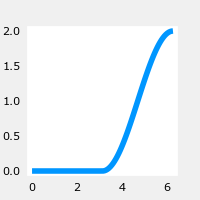

In [10]:
X = np.linspace(0,2*np.pi, 100)
y = np.cos(X)+1
y[0:49]=0
fig,ax = plt.subplots(1,1, figsize=(2,2))
widgvis(fig)
ax.plot(X,y)
plt.show()

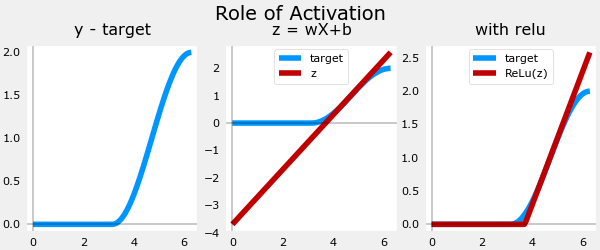

In [11]:
w11 = np.array([[1]])
b11 = np.array([-3.7])

# 创建Dense层
d11 = Dense(1, activation = "linear")

# 构建模型（需要先构建才能设置权重）
input_tensor = tf.keras.Input(shape=(1,))
output_tensor = d11(input_tensor)

# 设置权重和偏置
d11.set_weights([w11, b11])

z11 = d11(X.reshape(-1,1))
a11 = relu(z11)
ax = plt_act1(y,z11,a11)

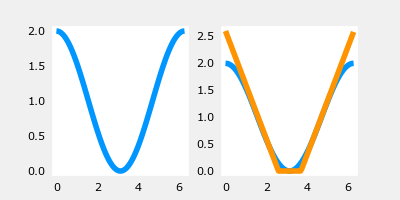

In [12]:
X = np.linspace(0,2*np.pi, 100)
y = np.cos(X)+1
X=X.reshape(-1,1)
yhat = relu(d10(X)) + relu(d11(X))

fig,ax = plt.subplots(1,2, figsize=(4,2))
widgvis(fig)
ax[0].plot(X,y)
ax[1].plot(X,y)
ax[1].plot(X,yhat)
plt.show()

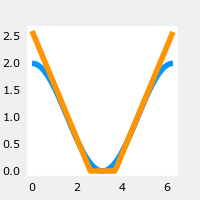

In [13]:
X=X.reshape(-1,1)
yhat = relu(d10(X)) + relu(d11(X))
fig,ax = plt.subplots(1,1, figsize=(2,2))
widgvis(fig)
ax.plot(X,y)
ax.plot(X,yhat)
plt.show()

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 


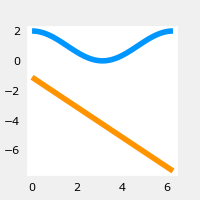

In [14]:
model = Sequential(
    [
        input_tensor,
        d10,
        d11
    ]
)
yhat = model.predict(X.reshape(-1,1))
fig,ax = plt.subplots(1,1, figsize=(2,2))
widgvis(fig)
ax.plot(X,y)
ax.plot(X,yhat)
plt.show()

In [15]:
model = Sequential(
    [ 
        d10,
        layers.Activation(tf.nn.relu),
        d11,
        layers.Activation(tf.nn.relu),
        Dense(1, activation = 'linear')
    ]
)
model.compile(
    loss=tf.keras.losses.MeanSquaredError(),
    optimizer=tf.keras.optimizers.Adam(0.1),
)

model.fit(
    X,y,
    epochs=100
)

Epoch 1/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.3302  
Epoch 2/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.8057
Epoch 3/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.5500
Epoch 4/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.5193
Epoch 5/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.5591
Epoch 6/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.5801
Epoch 7/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.5531
Epoch 8/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.5291
Epoch 9/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.5100
Epoch 10/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.5044
Epoch 11/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.5073
Epoch 12/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.5061
Epoch 13/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.5068
Epoch 14/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.5085
Epoch 15/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.5087
Epoch 16/100
4/4 ━━━━━━━━━━━━━━━

In [16]:
model = Sequential(
    [ 
        Dense(1,activation="relu", name = 'l1'),
        Dense(1,activation="linear", name = 'l2')
    ]
)
model.compile(
    loss=tf.keras.losses.MeanSquaredError(),
    optimizer=tf.keras.optimizers.Adam(0.01),
)

model.fit(
    X,y,
    epochs=10
)

Epoch 1/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 47.0751  
Epoch 2/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 40.6485 
Epoch 3/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 35.1602 
Epoch 4/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 30.0756
Epoch 5/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 25.7610 
Epoch 6/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 21.9061 
Epoch 7/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 18.6494
Epoch 8/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 15.7929
Epoch 9/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 13.4304
Epoch 10/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 11.4418


In [17]:
yhat = model.predict(X)
yhat[0:5]

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 


array([[-0.36],
       [-0.36],
       [-0.36],
       [-0.36],
       [-0.36]], dtype=float32)

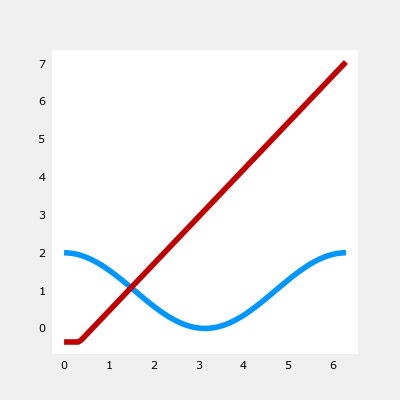

In [18]:
fig,ax = plt.subplots(1,1, figsize=(4,4))
ax.plot(X,y)
ax.plot(X,yhat, c=dlc["dldarkred"])
plt.show()

In [19]:
l1 = model.get_layer('l1')
l2 = model.get_layer('l2')

In [20]:
l1.get_weights()

[array([[1.03]], dtype=float32), array([-0.35], dtype=float32)]

In [21]:
l2.get_weights()

[array([[1.21]], dtype=float32), array([-0.36], dtype=float32)]

In [22]:
l1 = model.get_layer('l1')
l2 = model.get_layer('l2')
l1.get_weights()
l2.get_weights()

w1 = np.array([[-1]])
b1 = np.array([1])
l1.set_weights([w1,b1])

w2 = np.array([[1]])
b2 = np.array([0])
l2.set_weights([w2,b2])
model.fit(
    X,y,
    epochs=100
)

Epoch 1/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.2774
Epoch 2/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.3296
Epoch 3/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.3564 
Epoch 4/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.3667
Epoch 5/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.3661 
Epoch 6/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.3571 
Epoch 7/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.3432
Epoch 8/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.3248
Epoch 9/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.3049
Epoch 10/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.2826
Epoch 11/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.2599
Epoch 12/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.2372
Epoch 13/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.2128
Epoch 14/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.1894
Epoch 15/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.1636
Epoch 16/100
4/4 ━━━━━━━━━━━━━━

In [23]:
l2.set_weights([w2,b2])

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


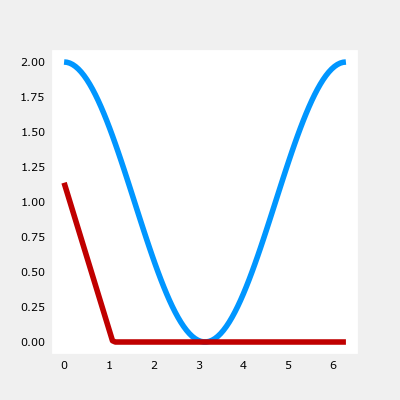

In [24]:
yhat = model.predict(X)
fig,ax = plt.subplots(1,1, figsize=(4,4))
ax.plot(X,y)
ax.plot(X,yhat, c=dlc["dldarkred"])
plt.show()

## 2-D

In [25]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib as mpl
import warnings
from matplotlib import cm
from matplotlib.patches import FancyArrowPatch
from matplotlib.colors import ListedColormap, LinearSegmentedColormap
import matplotlib.colors as colors
from lab_utils_common import dlc
dkcolors = plt.cm.Paired((1,3,7,9,5,11))
ltcolors = plt.cm.Paired((0,2,6,8,4,10))
dkcolors_map = mpl.colors.ListedColormap(dkcolors)
ltcolors_map = mpl.colors.ListedColormap(ltcolors)



In [26]:
def plt_mc_data(ax, X, y, classes,  class_labels=None, map=plt.cm.Paired, 
                legend=False, size=50, m='o', equal_xy = False):
    """ Plot multiclass data. Note, if equal_xy is True, setting ylim on the plot may not work """
    for i in range(classes):
        idx = np.where(y == i)
        col = len(idx[0])*[i]
        label = class_labels[i] if class_labels else "c{}".format(i)
        ax.scatter(X[idx, 0], X[idx, 1],  marker=m,
                    c=col, vmin=0, vmax=map.N, cmap=map,
                    s=size, label=label)
    if legend: ax.legend()
    if equal_xy: ax.axis("equal")

def plt_mc(X_train,y_train,classes):
    css = np.unique(y_train)
    fig,ax = plt.subplots(1,1,figsize=(3,3))
    fig.canvas.toolbar_visible = False
    fig.canvas.header_visible = False
    fig.canvas.footer_visible = False
    plt_mc_data(ax, X_train,y_train,classes, map=dkcolors_map, legend=True, size=10, equal_xy = False)
    ax.set_title("Multiclass Data")
    ax.set_xlabel("x0")
    ax.set_ylabel("x1")
    return(ax)
    
def plot_cat_decision_boundary_mc(ax, X, predict , class_labels=None, legend=False, vector=True):

    # create a mesh to points to plot
    x_min, x_max = X[:, 0].min(), X[:, 0].max()
    y_min, y_max = X[:, 1].min(), X[:, 1].max()
    h = max(x_max-x_min, y_max-y_min)/200
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))
    points = np.c_[xx.ravel(), yy.ravel()]
    #print("points", points.shape)
    #print("xx.shape", xx.shape)

    #make predictions for each point in mesh
    if vector:
        Z = predict(points)
    else:
        Z = np.zeros((len(points),))
        for i in range(len(points)):
            Z[i] = predict(points[i].reshape(1,2))
    Z = Z.reshape(xx.shape)

    #contour plot highlights boundaries between values - classes in this case
    ax.contour(xx, yy, Z, linewidths=1) 
    #ax.axis('tight')


<AxesSubplot: title={'center': 'Multiclass Data'}, xlabel='x0', ylabel='x1'>

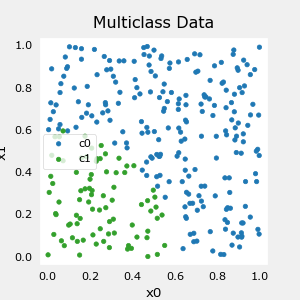

In [27]:
X = np.random.rand(300, 2)
y = np.sqrt( X[:,0]**2 + X[:,1]**2 ) < 0.6
#y = np.logical_and( X[:,0] < 0.5, X[:,1] < 0.5 ).astype(int)
y.shape
plt_mc(X,y,2,)

In [28]:
model = Sequential(
    [ 
        Dense(2,activation="relu",    name = 'l1'),
        Dense(1,activation="sigmoid", name = 'l2')
    ]
)

model.compile(
    loss=tf.keras.losses.MeanSquaredError(),
    optimizer=tf.keras.optimizers.Adam(0.01),
)

model.fit(
    X,y,
    epochs=150
)

Epoch 1/150
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.2213  
Epoch 2/150
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.1933
Epoch 3/150
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.1758
Epoch 4/150
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.1695 
Epoch 5/150
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1621 
Epoch 6/150
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.1536 
Epoch 7/150
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.1462
Epoch 8/150
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1391
Epoch 9/150
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.1319
Epoch 10/150
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1259
Epoch 11/150
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1195 
Epoch 12/150
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.1139
Epoch 13/150
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1083
Epoch 14/150
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.1033 
Epoch 15/150
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.09

1250/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 215us/step


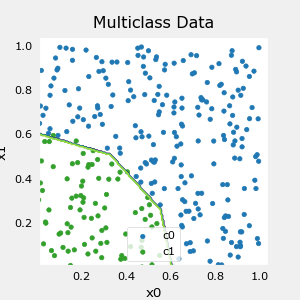

In [29]:
ax = plt_mc(X,y,2,)
predict = lambda  x: (model.predict(x) > 0.5).astype(int)
plot_cat_decision_boundary_mc(ax, X, predict, legend = True, vector=True)

In [30]:
l1 = model.get_layer("l1")
W1,b1 = l1.get_weights()
l2 = model.get_layer("l2")
W2,b2 = l2.get_weights()
print(W1,b1)
print(W2,b2)

[[2.83 0.8 ]
 [0.56 2.73]] [-1.22 -1.15]
[[-6.26]
 [-6.25]] [3.11]


In [31]:
x0 = np.array([0.4,0.60])
np.dot( np.dot(x0,W1) + b1, W2) + b2

array([-3.48])

In [32]:
## Example

(500, 2) MiniBatchKMeans(n_clusters=3)
(500, 2) AffinityPropagation(damping=0.9, preference=-200, random_state=0)
(500, 2) MeanShift(bandwidth=1.321267758400405, bin_seeding=True)
(500, 2) SpectralClustering(affinity='nearest_neighbors', eigen_solver='arpack',
                   n_clusters=3)
(500, 2) AgglomerativeClustering(connectivity=<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 1892 stored elements and shape (500, 500)>,
                        n_clusters=3)
(500, 2) AgglomerativeClustering(connectivity=<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 1892 stored elements and shape (500, 500)>,
                        linkage='average', metric='cityblock', n_clusters=3)
(500, 2) DBSCAN(eps=0.3)
(500, 2) OPTICS(min_cluster_size=0.1, min_samples=7)
(500, 2) Birch()
(500, 2) GaussianMixture(n_components=3)


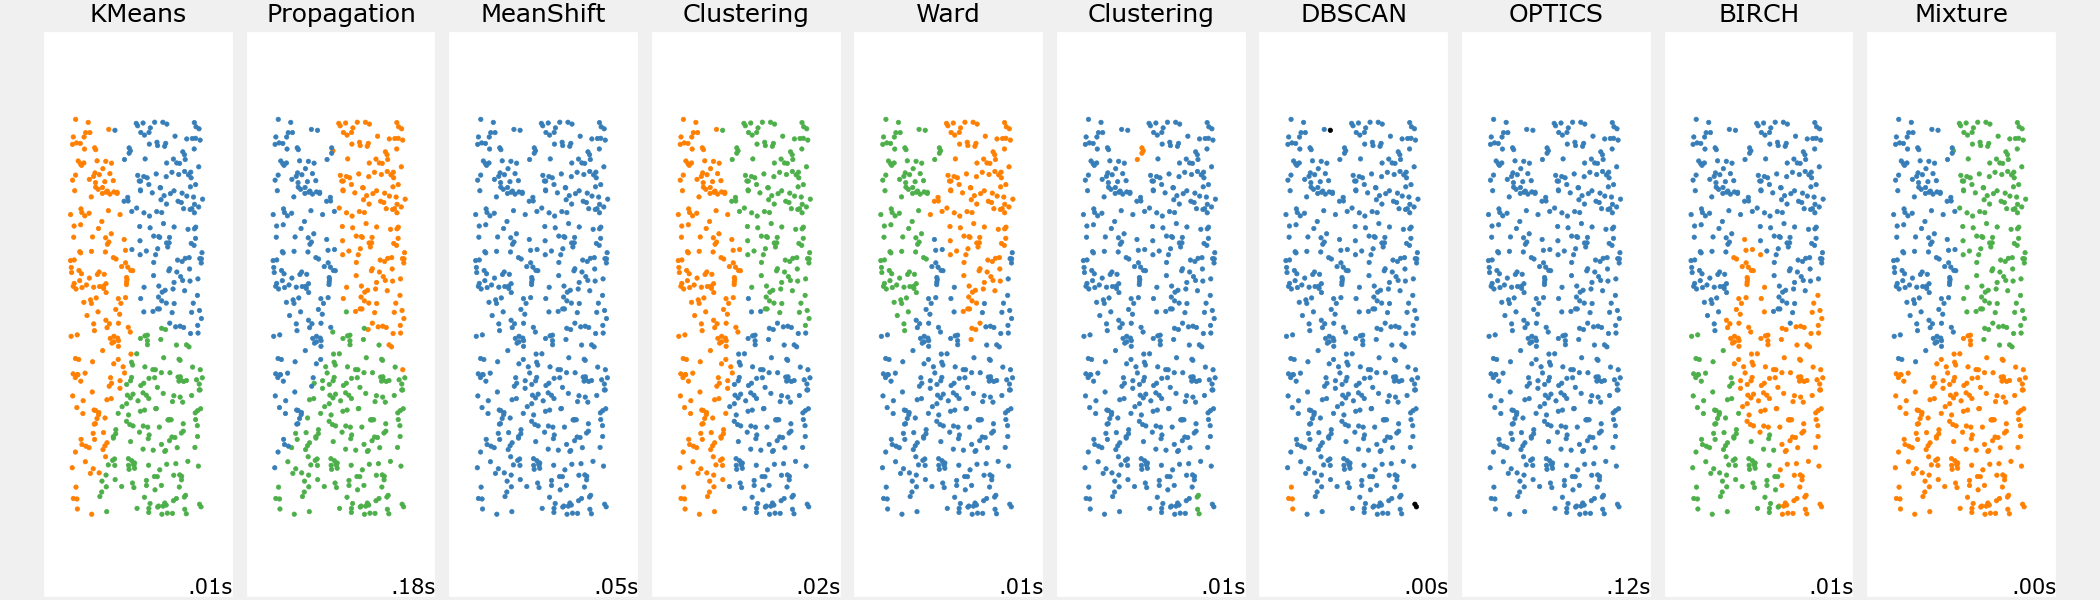

In [36]:
import time
import warnings

import numpy as np
import matplotlib.pyplot as plt

from sklearn import cluster, datasets, mixture
from sklearn.neighbors import kneighbors_graph
from sklearn.preprocessing import StandardScaler
from itertools import cycle, islice

np.random.seed(0)

# ============
# Generate datasets. We choose the size big enough to see the scalability
# of the algorithms, but not too big to avoid too long running times
# ============
n_samples = 500
noisy_circles = datasets.make_circles(n_samples=n_samples, factor=0.5, noise=0.05)
noisy_moons = datasets.make_moons(n_samples=n_samples, noise=0.05)
blobs = datasets.make_blobs(n_samples=n_samples, random_state=8)
no_structure = np.random.rand(n_samples, 2), None

# Anisotropicly distributed data
random_state = 170
X, y = datasets.make_blobs(n_samples=n_samples, random_state=random_state)
transformation = [[0.6, -0.6], [-0.4, 0.8]]
X_aniso = np.dot(X, transformation)
aniso = (X_aniso, y)

# blobs with varied variances
varied = datasets.make_blobs(
    n_samples=n_samples, cluster_std=[1.0, 2.5, 0.5], random_state=random_state
)

# ============
# Set up cluster parameters
# ============
plt.figure(figsize=(9 * 2 + 3, 6))
plt.subplots_adjust(
    left=0.02, right=0.98, bottom=0.001, top=0.95, wspace=0.05, hspace=0.01
)

plot_num = 1

default_base = {
    "quantile": 0.3,
    "eps": 0.3,
    "damping": 0.9,
    "preference": -200,
    "n_neighbors": 3,
    "n_clusters": 3,
    "min_samples": 7,
    "xi": 0.05,
    "min_cluster_size": 0.1,
}

datasets = [
    (
        noisy_circles,
        {
            "damping": 0.77,
            "preference": -240,
            "quantile": 0.2,
            "n_clusters": 2,
            "min_samples": 7,
            "xi": 0.08,
        },
    ),
    (
        noisy_moons,
        {
            "damping": 0.75,
            "preference": -220,
            "n_clusters": 2,
            "min_samples": 7,
            "xi": 0.1,
        },
    ),
    (
        varied,
        {
            "eps": 0.18,
            "n_neighbors": 2,
            "min_samples": 7,
            "xi": 0.01,
            "min_cluster_size": 0.2,
        },
    ),
    (
        aniso,
        {
            "eps": 0.15,
            "n_neighbors": 2,
            "min_samples": 7,
            "xi": 0.1,
            "min_cluster_size": 0.2,
        },
    ),
    (blobs, {"min_samples": 7, "xi": 0.1, "min_cluster_size": 0.2}),
    (no_structure, {}),
]

datasets = [
    (no_structure, {}),
]

for i_dataset, (dataset, algo_params) in enumerate(datasets):
    # update parameters with dataset-specific values
    params = default_base.copy()
    params.update(algo_params)

    X, y = dataset

    # normalize dataset for easier parameter selection
    X = StandardScaler().fit_transform(X)

    # estimate bandwidth for mean shift
    bandwidth = cluster.estimate_bandwidth(X, quantile=params["quantile"])

    # connectivity matrix for structured Ward
    connectivity = kneighbors_graph(
        X, n_neighbors=params["n_neighbors"], include_self=False
    )
    # make connectivity symmetric
    connectivity = 0.5 * (connectivity + connectivity.T)

    # ============
    # Create cluster objects
    # ============
    ms = cluster.MeanShift(bandwidth=bandwidth, bin_seeding=True)
    two_means = cluster.MiniBatchKMeans(n_clusters=params["n_clusters"])
    ward = cluster.AgglomerativeClustering(
        n_clusters=params["n_clusters"], linkage="ward", connectivity=connectivity
    )
    spectral = cluster.SpectralClustering(
        n_clusters=params["n_clusters"],
        eigen_solver="arpack",
        affinity="nearest_neighbors",
    )
    dbscan = cluster.DBSCAN(eps=params["eps"])
    optics = cluster.OPTICS(
        min_samples=params["min_samples"],
        xi=params["xi"],
        min_cluster_size=params["min_cluster_size"],
    )
    affinity_propagation = cluster.AffinityPropagation(
        damping=params["damping"], preference=params["preference"], random_state=0
    )
    average_linkage = cluster.AgglomerativeClustering(
        linkage="average",
        metric="cityblock",
        #affinity="cityblock",
        n_clusters=params["n_clusters"],
        connectivity=connectivity,
    )
    birch = cluster.Birch(n_clusters=params["n_clusters"])
    gmm = mixture.GaussianMixture(
        n_components=params["n_clusters"], covariance_type="full"
    )

    clustering_algorithms = (
        ("MiniBatch\nKMeans", two_means),
        ("Affinity\nPropagation", affinity_propagation),
        ("MeanShift", ms),
        ("Spectral\nClustering", spectral),
        ("Ward", ward),
        ("Agglomerative\nClustering", average_linkage),
        ("DBSCAN", dbscan),
        ("OPTICS", optics),
        ("BIRCH", birch),
        ("Gaussian\nMixture", gmm),
    )

    for name, algorithm in clustering_algorithms:
        t0 = time.time()

        # catch warnings related to kneighbors_graph
        with warnings.catch_warnings():
            warnings.filterwarnings(
                "ignore",
                message="the number of connected components of the "
                + "connectivity matrix is [0-9]{1,2}"
                + " > 1. Completing it to avoid stopping the tree early.",
                category=UserWarning,
            )
            warnings.filterwarnings(
                "ignore",
                message="Graph is not fully connected, spectral embedding"
                + " may not work as expected.",
                category=UserWarning,
            )
            print(X.shape,algorithm)
            algorithm.fit(X)

        t1 = time.time()
        if hasattr(algorithm, "labels_"):
            y_pred = algorithm.labels_.astype(int)
        else:
            y_pred = algorithm.predict(X)

        plt.subplot(len(datasets), len(clustering_algorithms), plot_num)
        if i_dataset == 0:
            plt.title(name, size=18)

        colors = np.array(
            list(
                islice(
                    cycle(
                        [
                            "#377eb8",
                            "#ff7f00",
                            "#4daf4a",
                            "#f781bf",
                            "#a65628",
                            "#984ea3",
                            "#999999",
                            "#e41a1c",
                            "#dede00",
                        ]
                    ),
                    int(max(y_pred) + 1),
                )
            )
        )
        # add black color for outliers (if any)
        colors = np.append(colors, ["#000000"])
        plt.scatter(X[:, 0], X[:, 1], s=10, color=colors[y_pred])

        plt.xlim(-2.5, 2.5)
        plt.ylim(-2.5, 2.5)
        plt.xticks(())
        plt.yticks(())
        plt.text(
            0.99,
            0.01,
            ("%.2fs" % (t1 - t0)).lstrip("0"),
            transform=plt.gca().transAxes,
            size=15,
            horizontalalignment="right",
        )
        plot_num += 1

plt.show()